# Gibbs sampling on a directed factor graph


<div class="note"><span class="note-t">TL;DR</span>
<p>We build a 4x4 Ising Gibbs sampler from a one-spin factor, checkerboard tiling, and a repeated directed factor graph. We check zero-field sampling, temperature sweeps, and field-driven pattern completion against exact enumeration.</p>
</div>

<div class="note"><span class="note-t">Prerequisite</span>
<p>For background on factors, <a href="15_intro_to_factors.ipynb">15 &middot; Introduction to factors and directed factor graphs</a> introduces the core abstraction before this full Ising sampler.</p>
</div>

A **factor** in Torx is a directed conditional $P(\text{output} \mid \text{inputs})$. A custom factor supplies its input and output specs along with `sample` and `init_params`. The one-spin factor here also implements an exact `log_probability`, so it is its own analytic reference.

A parametrised stochastic circuit (PSC) is an ordered list of stochastic gates applied to an initial state. This tutorial uses no PSC, compiled circuit, or simulator; we work directly with hand-written factors.

Gibbs sampling updates one variable at a time from its conditional, and it is not the main use case Torx is built for. For a dedicated Gibbs sampling library, use [thrml](https://github.com/extropic-ai/thrml). Gibbs sampling is useful here because it touches the full `DFG` workflow: a custom factor with an analytic conditional, weight tying, tiling, deterministic reassembly, and an exact finite-state reference.

The coloring idea comes from [notebook 06](06_ising_sampling_contrastive_divergence.ipynb), where the lattice is colored so non-adjacent spins update together. Notebook 06 runs that idea on an 8-spin ring with `PNOT` gates; here we write the same chromatic-Gibbs conditional as hand-built factors on a $4\times4$ torus. The two notebooks share the conditional update and the coloring strategy but use different graphs and Ising distributions.

The graph receives the per-site `field` as an input rather than a baked-in weight. With a zero field the model is the symmetric Ising magnet, and with a field that pins a few sites the same graph completes a clamped pattern.

The grid is a $4\times4$ torus, small enough that all $2^{16} = 65{,}536$ configurations fit in memory. The exact distribution is available by brute force for any fixed field, and every check compares against it.

The main steps are:

1. set up the $4\times4$ Boltzmann machine and draw its `DFG`,
2. write the one-spin update as a custom factor, probe that its draw lands on $\sigma(2\gamma)$, and read back its exact `log_probability`,
3. tile the update into two color blocks and wire them into an explicit `DFG` for one Gibbs sweep,
4. repeat that sweep as a weight-tied chain, build the exact distribution by brute-force enumeration, and check the sampler against it,
5. sweep the temperature and watch the magnet order as it cools,
6. match the sampler spin by spin and connection by connection against it, and
7. drive the graph with a field to clamp a pattern and complete it.

## Setup

The setup cells configure the local helper path, then fix the plotting style and seed.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))

In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_sampling as P_samp
import _plots_schematics as P_sch



In [4]:
from torx import (
    AbstractHasLogProbability,
    AbstractReferenceFactor,
    ChainFactor,
    DeterministicFactor,
    DFG,
    Site,
    TiledFactor,
)

In [5]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 15
rng = np.random.default_rng(SEED)


savefig = make_savefig(FIGURE_DIR)

## The model as a Boltzmann machine

The model is a $4\times4$ grid of spins with periodic boundaries, so every spin has exactly four neighbors.

The grid holds 16 spins and 32 connections. The state is stored as spins $s \in \{-1, +1\}$. Internally, each update draws a Bernoulli **pbit** in $\{0, 1\}$ and maps it to the stored spin via $s = 2\,\text{pbit} - 1$. The neighbor lists, connection list, and checkerboard coloring come from a notebook helper (`examples/helpers/_plots_schematics.py`).

Neighboring spins prefer to agree, and a per-site field $b_i$ biases each spin.

$$
H(s) = -J\,\sum_{(i,j)\in E} s_i\, s_j \;-\; \sum_i b_i\, s_i,
\qquad \pi(s) \propto e^{-\beta H(s)}.
$$

Lower energy means higher probability, and $\beta$ is the inverse temperature.

With $b = 0$ the model is the symmetric Ising magnet, and setting $b$ to a pattern clamps that pattern.

In [6]:
GRID = 4
N = GRID * GRID
J = 1.0  # ferromagnetic coupling: neighbors prefer to agree
beta = 0.45  # baseline inverse temperature (past the finite-size ordering crossover)

EDGES = P_sch.lattice_edges()
COLOR_A, COLOR_B = P_sch.checkerboard_colors()
NEIGHBORS_OF = [P_sch.lattice_neighbors(i) for i in range(N)]

print(
    f"{N} spins, {len(EDGES)} connections, two colors of size "
    f"{len(COLOR_A)} and {len(COLOR_B)}"
)
print(f"every spin has {len(NEIGHBORS_OF[0])} neighbors (periodic)")

16 spins, 32 connections, two colors of size 8 and 8
every spin has 4 neighbors (periodic)


Here is the $4\times4$ lattice the `DFG` will sweep.

The 16 spins split into two color blocks. The solid links are the neighbor dependencies inside the grid, and the dashed stubs are the periodic wrap-around connections that close the lattice into a torus. A spin reads its four neighbors, all of which lie in the other block.

The two colors are the two checkerboard update groups. Color `A` reads the incoming state, and color `B` reads the updated color `A`.

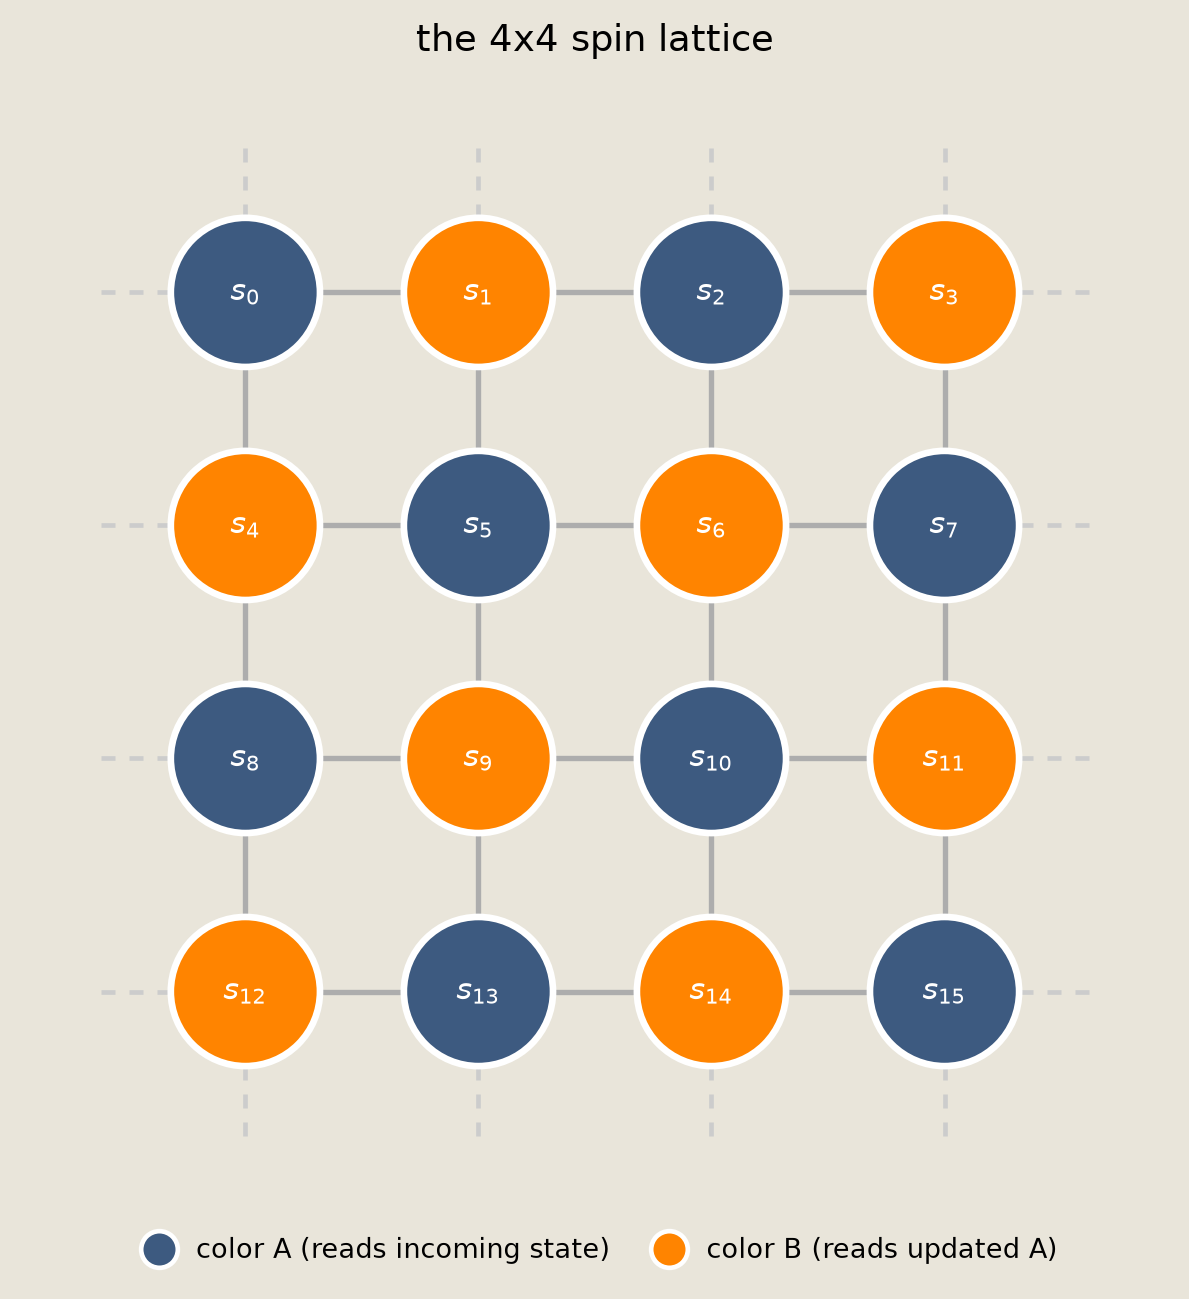

In [7]:
fig = P_sch.plot_factor_graph()
savefig(fig, "16_factor_graph")

## The per-spin update as a factor

The smallest piece of the model is a single spin update: given a spin's four neighbors and its local `drive`, draw its new value.

That update is one factor: a directed conditional that implements `sample` and `init_params` alongside its specs.

The update draws a Bernoulli pbit in $\{0, 1\}$ with probability $\sigma(2\gamma_i)$, then maps it to the stored spin $s_i = 2\,\text{pbit} - 1 \in \{-1, +1\}$. Here $\sigma$ is the logistic sigmoid and the local field $\gamma_i$ collects the neighbors and the `drive`.

The draw uses `jax.random.bernoulli`. The `drive` and the coupling parameter the kernel consumes already carry the inverse temperature $\beta$: we supply $\text{drive}_i = \beta\,b_i$ and $j = \beta J$, so $\gamma_i$ is the $\beta$-scaled local field. The brute-force `exact_distribution` below instead takes the raw physical field $b_i$ and applies $\beta$ itself.

$$
\gamma_i = \beta\,b_i + \beta J\,\sum_{j\in\mathcal{N}(i)} s_j,
\qquad
P(s_i = +1 \mid \mathcal{N}(i),\, b_i) = \sigma(2\gamma_i).
$$

In [8]:
SPIN = jax.ShapeDtypeStruct((), jnp.int32)  # one spin, -1 or +1
NEIGHBORS = jax.ShapeDtypeStruct((4,), jnp.int32)  # its four neighbor spins
DRIVE = jax.ShapeDtypeStruct((), jnp.float32)  # this spin's local drive (beta * b_i)




In [9]:
class SpinUpdate(AbstractReferenceFactor, AbstractHasLogProbability):
    r"""$P(s_i \mid \mathcal{N}(i))$: stored as a spin in $\{-1, +1\}$, drawn via one
    Bernoulli pbit with probability $\sigma(2\gamma_i)$ then mapped to a spin.

    The `drive` input is the temperature-scaled bias `beta * b_i`; the raw
    field `b_i` is scaled before it reaches the kernel. Besides the
    specs, a custom factor implements `sample` and `init_params`, and
    `AbstractReferenceFactor` supplies the generic `sample_with_references`; this
    conditional is analytic, so it also reports an exact `log_probability` and is a
    self-contained Gibbs kernel.
    """

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)

    def __init__(self):
        self.input_ports = {"neighbors": NEIGHBORS, "drive": DRIVE}
        self.output_spec = SPIN

    def init_params(self, key):
        return {"j": jnp.zeros((), jnp.float32)}

    def _local_field(self, inputs, params):
        return inputs["drive"] + params["j"] * inputs["neighbors"].sum()

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        # draw a Bernoulli pbit in {0, 1}, then map to the stored spin {-1, +1}
        draw = jax.random.bernoulli(
            key, jax.nn.sigmoid(2 * self._local_field(inputs, params))
        ).astype(jnp.int32)
        spin = 2 * draw - 1
        return (spin, None) if return_aux else spin

    def log_probability(
        self, inputs, outputs, params, info=None, site_info=None, return_aux=False
    ):
        # P(s) = sigmoid(2 * gamma * s) for s in {-1, +1}; invalid spins get -inf
        valid = (outputs == 1) | (outputs == -1)
        log_prob = jnp.where(
            valid,
            jax.nn.log_sigmoid(2 * self._local_field(inputs, params) * outputs),
            -jnp.inf,
        )
        return (log_prob, None) if return_aux else log_prob

Now we probe the factor. We fix the neighbors and `drive` by hand, compute the resulting local field $\gamma$, draw the update many times, and check that the fraction of $+1$ spins lands on $\sigma(2\gamma)$.

This is the single-spin check: the factor samples its conditional and reports the same conditional analytically.

In [10]:
probe = SpinUpdate()

probe_neighbors = jnp.array([1, 1, 1, -1], dtype=jnp.int32)  # sums to +2
probe_drive = 0.30  # scaled local bias the kernel consumes
probe_coupling = beta * J
probe_params = {"j": probe_coupling}
gamma = probe_drive + probe_coupling * probe_neighbors.sum()
target_p = float(jax.nn.sigmoid(2 * gamma))

n_probe = 20000
keys = jax.random.split(jax.random.key(SEED), n_probe)
inputs = {"neighbors": probe_neighbors, "drive": probe_drive}
draws = jax.vmap(lambda k: probe.sample(k, inputs, probe_params))(keys)
probe_p = float((np.asarray(draws) == 1).mean())

print(f"gamma = {float(gamma):.4f}  ->  target sigmoid(2*gamma) = {target_p:.4f}")
print(f"sampled fraction of +1 spins                     = {probe_p:.4f}")

gamma = 1.2000  ->  target sigmoid(2*gamma) = 0.9168
sampled fraction of +1 spins                     = 0.9183


With the empirical fraction matched, we read the same conditional back analytically. The analytic value should agree with the sampled one, and the two outcomes should sum to one.

In [11]:
logp_p_up = float(np.exp(probe.log_probability(inputs, 1, probe_params)))
logp_mass = float(
    np.exp(probe.log_probability(inputs, 1, probe_params))
    + np.exp(probe.log_probability(inputs, -1, probe_params))
)

print(
    f"log_probability gives P(+1) = {logp_p_up:.4f},  outcomes sum to {logp_mass:.6f}"
)
np.testing.assert_allclose(probe_p, target_p, atol=0.01)
np.testing.assert_allclose(logp_p_up, target_p, atol=1e-5)
np.testing.assert_allclose(logp_mass, 1.0, atol=1e-6)

log_probability gives P(+1) = 0.9168,  outcomes sum to 1.000000


## Wiring the lattice into a directed factor graph

The two checkerboard colors are the two Gibbs blocks. Every spin in a block updates from the same conditional, so each block is the single `SpinUpdate` factor wrapped in a `TiledFactor`: one tile per spin, eight tiles per block.

The tiles share one coupling, and each tile receives its own neighbors and `drive` as data. The geometry is fixed, so we precompute each tile's neighbor indices once.

In [12]:
SPINS = jax.ShapeDtypeStruct((N,), jnp.int32)  # the full state
DRIVES = jax.ShapeDtypeStruct((N,), jnp.float32)  # per-site drive (beta * field)
BLOCK = len(COLOR_A)  # 8 spins per color
BLOCK_SPINS = jax.ShapeDtypeStruct((BLOCK,), jnp.int32)



In [13]:
COLOR_A_IDX = jnp.array(COLOR_A, dtype=jnp.int32)
COLOR_B_IDX = jnp.array(COLOR_B, dtype=jnp.int32)
position_in_a = {site: tile for tile, site in enumerate(COLOR_A)}



In [14]:
# Per-tile neighbor lookups, fixed by the geometry. Color A reads its four
# neighbors out of the incoming state; color B reads them out of the freshly
# updated color A block (every neighbor of a color B site is a color A site).
A_NEIGHBORS = jnp.array([NEIGHBORS_OF[i] for i in COLOR_A], dtype=jnp.int32)
B_NEIGHBORS = jnp.array(
    [[position_in_a[j] for j in NEIGHBORS_OF[i]] for i in COLOR_B], dtype=jnp.int32
)

Each block needs a porting function that slices its tiles' neighbors and `drive` out of the parent outputs. A third function scatters the two blocks back into one state vector.

In [15]:
def gather_block_a(parent_outputs):
    spins, drives = parent_outputs
    return {"neighbors": spins[A_NEIGHBORS], "drive": drives[COLOR_A_IDX]}




In [16]:
def gather_block_b(parent_outputs):
    """Route block-A spins and B-site drives into block B's kernel inputs."""
    block_a, drives = parent_outputs
    return {"neighbors": block_a[B_NEIGHBORS], "drive": drives[COLOR_B_IDX]}




In [17]:
def scatter_blocks(inputs, site_info):
    """Place the two color blocks back into one lattice-ordered state vector."""
    state = jnp.zeros(N, dtype=jnp.int32)
    state = state.at[COLOR_A_IDX].set(inputs["block_a"])
    state = state.at[COLOR_B_IDX].set(inputs["block_b"])
    return state

In [18]:
block = TiledFactor(SpinUpdate(), BLOCK, weight_tied=True)  # 8 spins in parallel
reassemble = DeterministicFactor(
    scatter_blocks, {"block_a": BLOCK_SPINS, "block_b": BLOCK_SPINS}, SPINS
)

Finally, we wire the three `Site` objects into the `DFG` for one sweep.

Each block updates all of its spins in parallel, so each block appears in the graph as one tiled factor rather than eight separate `Site` objects.

In [19]:
sites = (
    Site(
        "block_a",
        block,
        parents=("spins", "drive"),
        porting_fn=gather_block_a,
        param_key="coupling",
        info_key=None,
        site_info=None,
    ),
    Site(
        "block_b",
        block,
        parents=("block_a", "drive"),
        porting_fn=gather_block_b,
        param_key="coupling",
        info_key=None,
        site_info=None,
    ),
    Site(
        "state",
        reassemble,
        parents=("block_a", "block_b"),
        porting_fn=("block_a", "block_b"),
        param_key=None,
        info_key=None,
        site_info=None,
    ),
)



In [20]:
sweep = DFG(
    sites=sites, input_ports={"spins": SPINS, "drive": DRIVES}, output_name="state"
)
print(
    f"directed factor graph: {len(sites)} sites "
    f"(2 tiled blocks of {BLOCK} + 1 reassembly)"
)

directed factor graph: 3 sites (2 tiled blocks of 8 + 1 reassembly)


## Running the chain

The `DFG` above computes one sweep, and the full sampler repeats it. A weight-tied `ChainFactor` runs the same sweep for many steps with one shared coupling; in Torx, this is the idiom for a Markov chain Monte Carlo (MCMC) chain.

The `drive` input, which carries the $\beta$-scaled field, is a non-feedback input, so the chain holds it fixed at every step and threads only the spins.

The early steps are warmup, which gives the chain time to settle. We run many independent chains and keep each final state as a set of equilibrium samples.

In [21]:
n_steps = 200  # Gibbs sweeps per chain
warmup = 80  # sweeps the settling plot marks as warmup
n_chains = 4000

chain = ChainFactor(sweep, n_steps=n_steps, feedback_porting_fn="spins", weight_tied=True)




In [22]:
def run(key, beta, init, field):
    # field is the raw physical field; scale it and the coupling by beta into the
    # drive the kernel consumes for this temperature.
    """Run the full `n_steps`-sweep chain at inverse temperature `beta`."""
    inputs = {"spins": init, "drive": beta * field}
    return chain.sample(key, inputs, params={"coupling": {"j": beta * J}})


@eqx.filter_jit
def run_many(keys, beta, inits, field):
    # reusable batched sampler; beta stays a traced scalar so changing the
    # temperature reuses this compile instead of recompiling per beta.
    """Batched `run` over chains."""
    return jax.vmap(lambda k, x: run(k, beta, x, field), in_axes=(0, 0))(keys, inits)




In [23]:
zero_field = jnp.zeros(N, dtype=jnp.float32)
inits = (
    jax.random.bernoulli(jax.random.key(SEED), 0.5, (n_chains, N)).astype(jnp.int32) * 2
    - 1
)
keys = jax.random.split(jax.random.key(SEED + 1), n_chains)
# Run independent chains from independent starts and keep the final states.
samples = np.asarray(
    run_many(keys, jnp.asarray(beta, jnp.float32), inits, zero_field)
)
print(f"drew {samples.shape[0]} equilibrium samples of {samples.shape[1]} spins each")

drew 4000 equilibrium samples of 16 spins each


To see warmup directly, we run many chains from a disordered start and track the **order parameter**: the magnitude of the average spin, averaged across chains at each step.

The bold line is that mean, and the band is the 16th to 84th percentile range across chains. It climbs from the disordered-start value (about 0.2) and settles during warmup.

Independent chains settle into either of the two mirror states, which is why the histogram below has both peaks.

The dashed line marks the end of warmup. The final states we keep come well after it.

In [24]:
n_burn = 1000  # chains tracked for the warmup trace
trace_init = (
    jax.random.bernoulli(jax.random.key(SEED + 2), 0.5, (n_burn, N)).astype(jnp.int32)
    * 2
    - 1
)




In [25]:
@eqx.filter_jit
def warmup_trace(key, init_state):
    # one lax.scan over sweeps, vmapped across chains: records the per-step order
    # parameter for every chain inside a single dispatch, no per-step host sync.
    """Record the per-sweep order parameter for every chain from a cold start."""
    def sweep_all(state, k):
        def one_sweep(kk, x):
            return sweep.sample(
                kk,
                {"spins": x, "drive": beta * zero_field},
                params={"coupling": {"j": beta * J}},
            )

        new = jax.vmap(one_sweep, in_axes=(0, 0))(
            jax.random.split(k, init_state.shape[0]), state
        )
        return new, jnp.abs(new.mean(axis=1))

    keys = jax.random.split(key, n_steps)
    _, orders = jax.lax.scan(sweep_all, init_state, keys)
    init_order = jnp.abs(init_state.mean(axis=1))
    return jnp.concatenate([init_order[None, :], orders], axis=0)




In [26]:
# (n_burn, n_steps + 1) for plotting
order_traces = np.asarray(warmup_trace(jax.random.key(SEED + 4), trace_init)).T

The per-step order parameter climbs out of the disordered start and flattens once the chain has settled. That flattening marks where warmup ends.

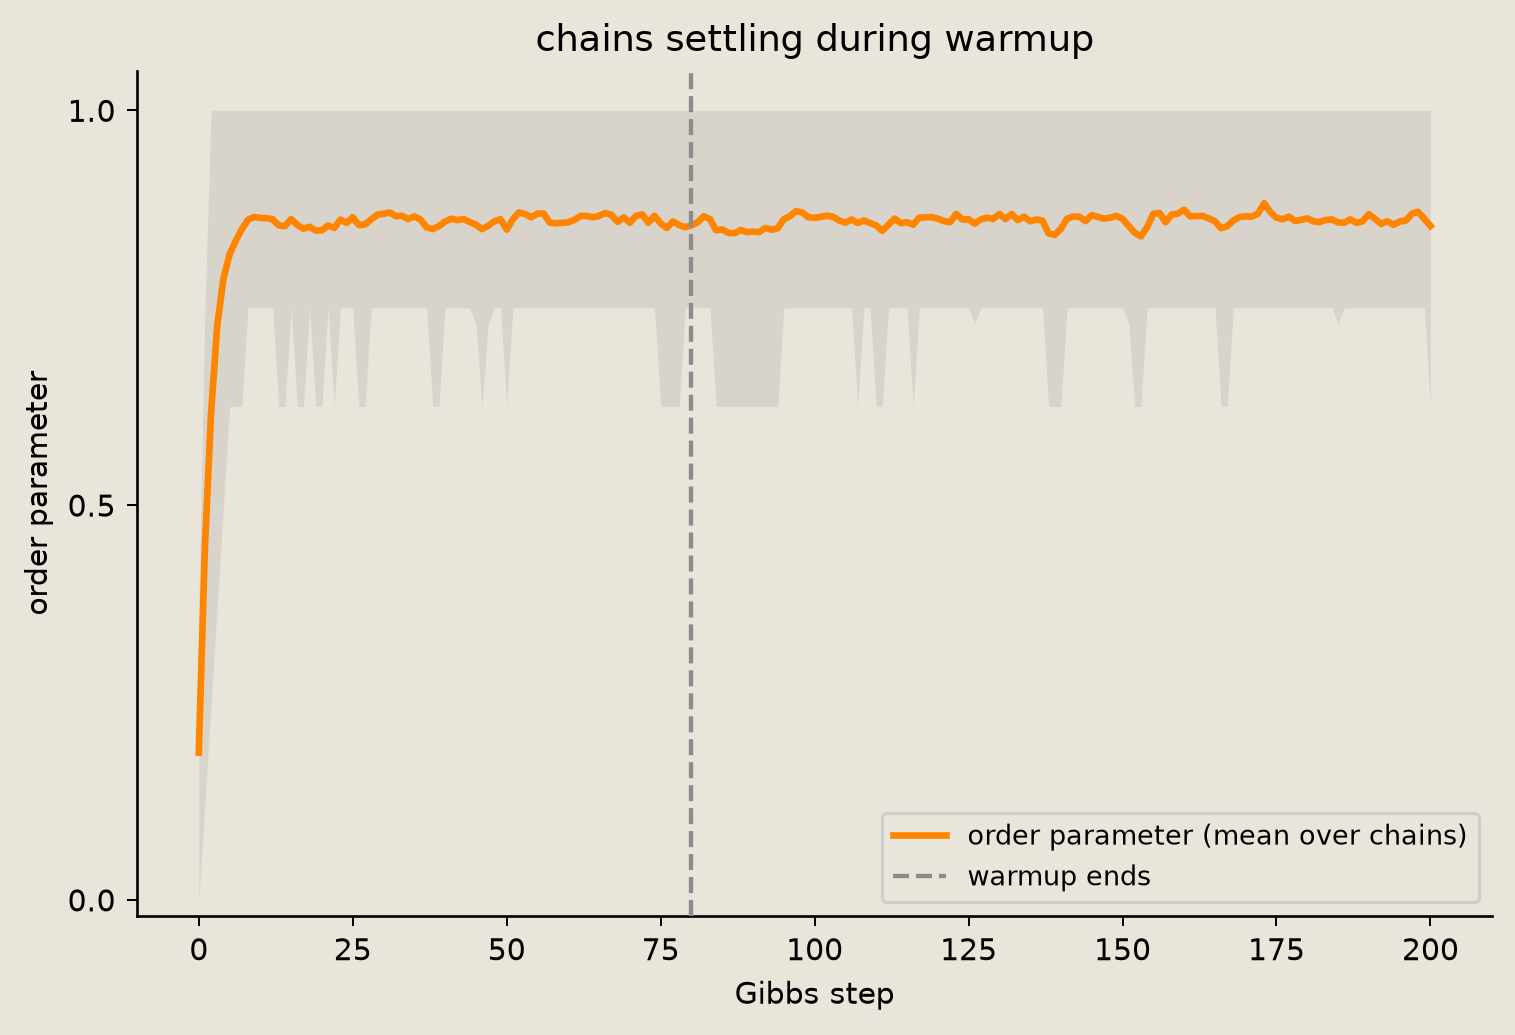

In [27]:
fig = P_samp.plot_settling_trace(order_traces, warmup=warmup)
savefig(fig, "16_settling_trace")

The first comparison uses the total magnetization, the sum of all spins in each sample. We enumerate the exact distribution for the zero-field case and compare it with the sampler.

The two peaks are the two mirror-image ordered states. We report the gap to the exact curve as one number, the total variation distance on the magnetization.

In [28]:
# Enumerate all 2**16 configurations once: bits and spins.
ALL_BITS = ((np.arange(2**N)[:, None] >> np.arange(N - 1, -1, -1)) & 1).astype(np.int8)
ALL_SPINS = (2 * ALL_BITS - 1).astype(np.int8)
edge_i = np.array([i for i, _ in EDGES])
edge_j = np.array([j for _, j in EDGES])




In [29]:
def exact_distribution(field):
    """Exact Boltzmann probabilities over all 2**16 configs for a fixed field."""
    agreement = (ALL_SPINS[:, edge_i] * ALL_SPINS[:, edge_j]).sum(axis=1)
    energy = -J * agreement - ALL_SPINS @ np.asarray(field, dtype=float)
    logp = -beta * energy
    logp -= logp.max()
    p = np.exp(logp)
    return p / p.sum()




In [30]:
exact_p = exact_distribution(np.zeros(N))
exact_mag = ALL_SPINS.sum(axis=1)

levels = np.arange(-N, N + 1, 2)
exact_level_probs = np.array([exact_p[exact_mag == m].sum() for m in levels])
sampler_mag = P_samp.total_magnetization(samples)
sampler_level_probs = np.array([(sampler_mag == m).mean() for m in levels])
mag_gap = (
    0.5 * np.abs(sampler_level_probs - exact_level_probs).sum()
)  # total variation on magnetization

print(f"exact distribution sums to {exact_p.sum():.6f}")
print(f"gap to exact (magnetization total variation) = {mag_gap:.4f}")

exact distribution sums to 1.000000
gap to exact (magnetization total variation) = 0.0222


Overlaid on the exact line, the sampled counts sit on both peaks with a matching trough between them.

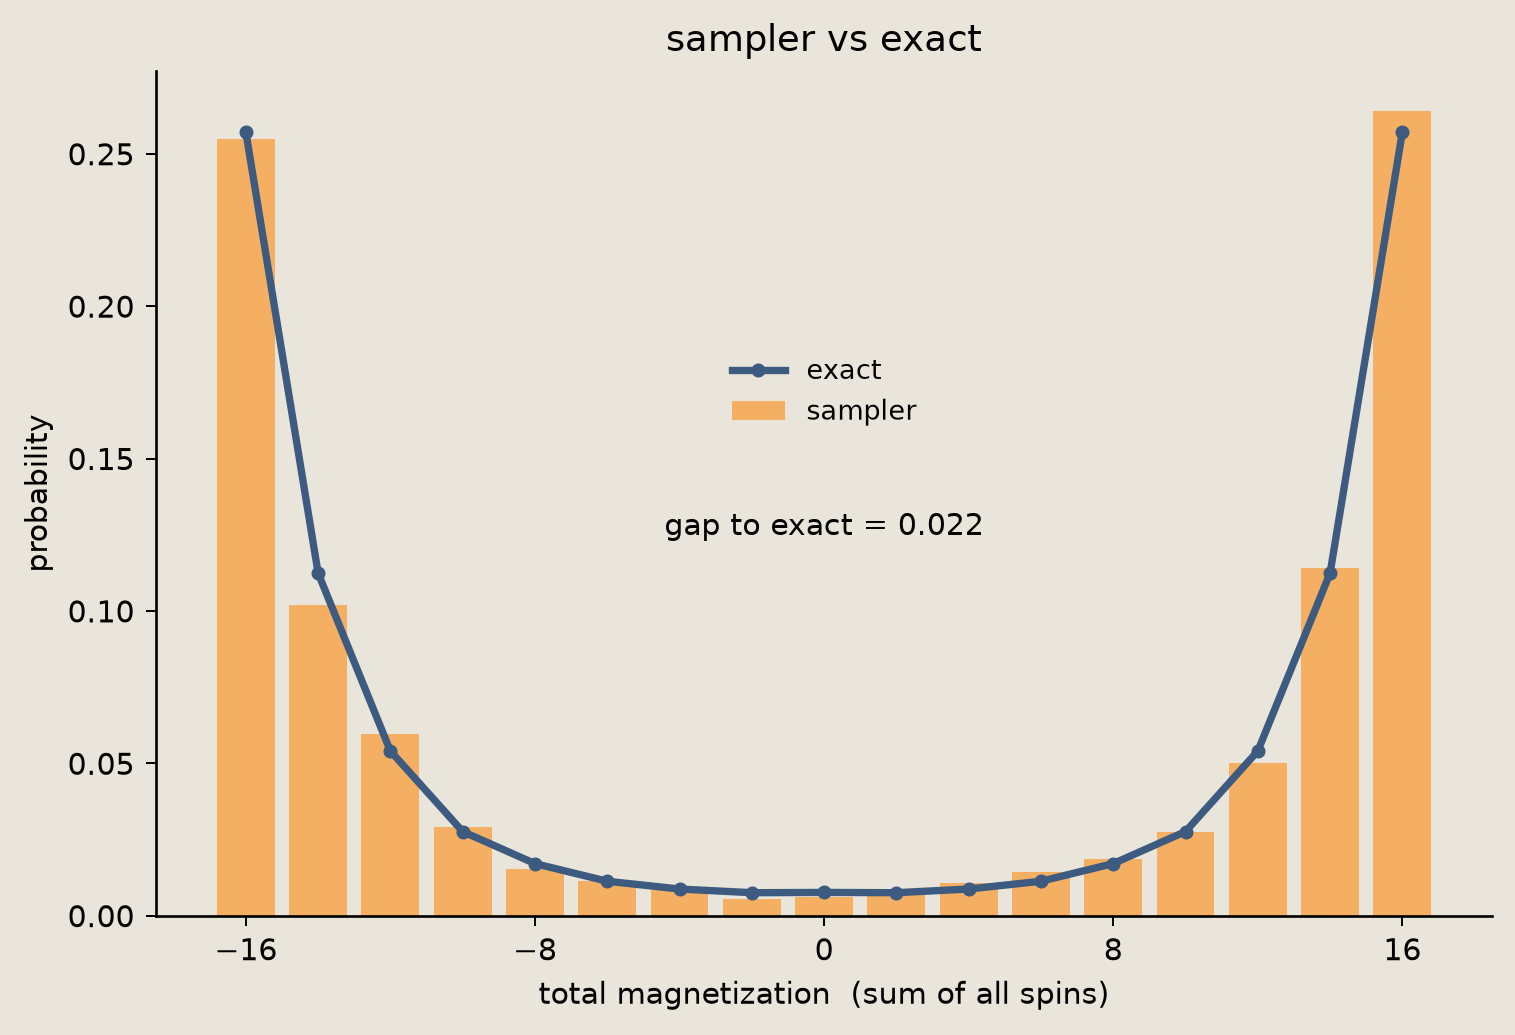

In [31]:
fig = P_samp.plot_magnetization_histogram_lattice(sampler_mag, levels, exact_level_probs, gap=mag_gap)
savefig(fig, "16_magnetization_vs_exact")

## Cooling the model

As the magnet cools, it orders. The order parameter measures how strongly it points in one direction, on a scale from 0 to 1.

We sweep several inverse temperatures and compare three curves: the exact answer by enumeration, the sampler, and the mean-field approximation. The sampler curve comes from the notebook helper `sweep_temperatures` in `examples/helpers/_plots_sampling.py`, which runs fresh chains at each inverse temperature and reports their order parameter. Mean-field replaces each spin's neighbors with their average, which overshoots near the finite-size crossover. Below its own critical point $\beta = 1/(4J) = 0.25$, mean-field predicts zero order, so its curve sits at zero for $\beta \le 0.2$ and only overshoots once it turns on. On this finite $4\times4$ torus there is no true phase transition; the crossover sits near the infinite-lattice critical inverse temperature.

In [32]:
def exact_order(beta_val):
    """Exact order parameter E|mean spin| at a given inverse temperature."""
    agreement = (ALL_SPINS[:, edge_i] * ALL_SPINS[:, edge_j]).sum(axis=1)
    logp = beta_val * (J * agreement)  # zero field
    logp -= logp.max()
    p = np.exp(logp)
    p /= p.sum()
    abs_mean_spin = np.abs(ALL_SPINS.mean(axis=1))
    return float((p * abs_mean_spin).sum())




In [33]:
def mean_field_order(beta_val, iters=500):
    """Self-consistent mean-field magnetization m = tanh(4*beta*J*m)."""
    m = 0.9
    for _ in range(iters):
        m = np.tanh(4.0 * beta_val * J * m)
    return abs(m)

In [34]:
betas = np.linspace(0.10, 0.60, 6)
exact_curve = np.array([exact_order(b) for b in betas])
mf_curve = np.array([mean_field_order(b) for b in betas])
sampler_curve = P_samp.sweep_temperatures(
    run,
    betas,
    n_chains=2000,
    seed=SEED + 10,
)

print("beta      exact   sampler  mean-field")
for b, e, s, m in zip(betas, exact_curve, sampler_curve, mf_curve, strict=True):
    print(f"{b:.2f}     {e:.3f}    {s:.3f}    {m:.3f}")

beta      exact   sampler  mean-field
0.10     0.249    0.246    0.000
0.20     0.343    0.343    0.000
0.30     0.520    0.512    0.659
0.40     0.765    0.776    0.891
0.50     0.919    0.926    0.958
0.60     0.973    0.972    0.982


Plotted together, the sampler tracks the exact curve while mean-field runs high near the finite-size crossover.

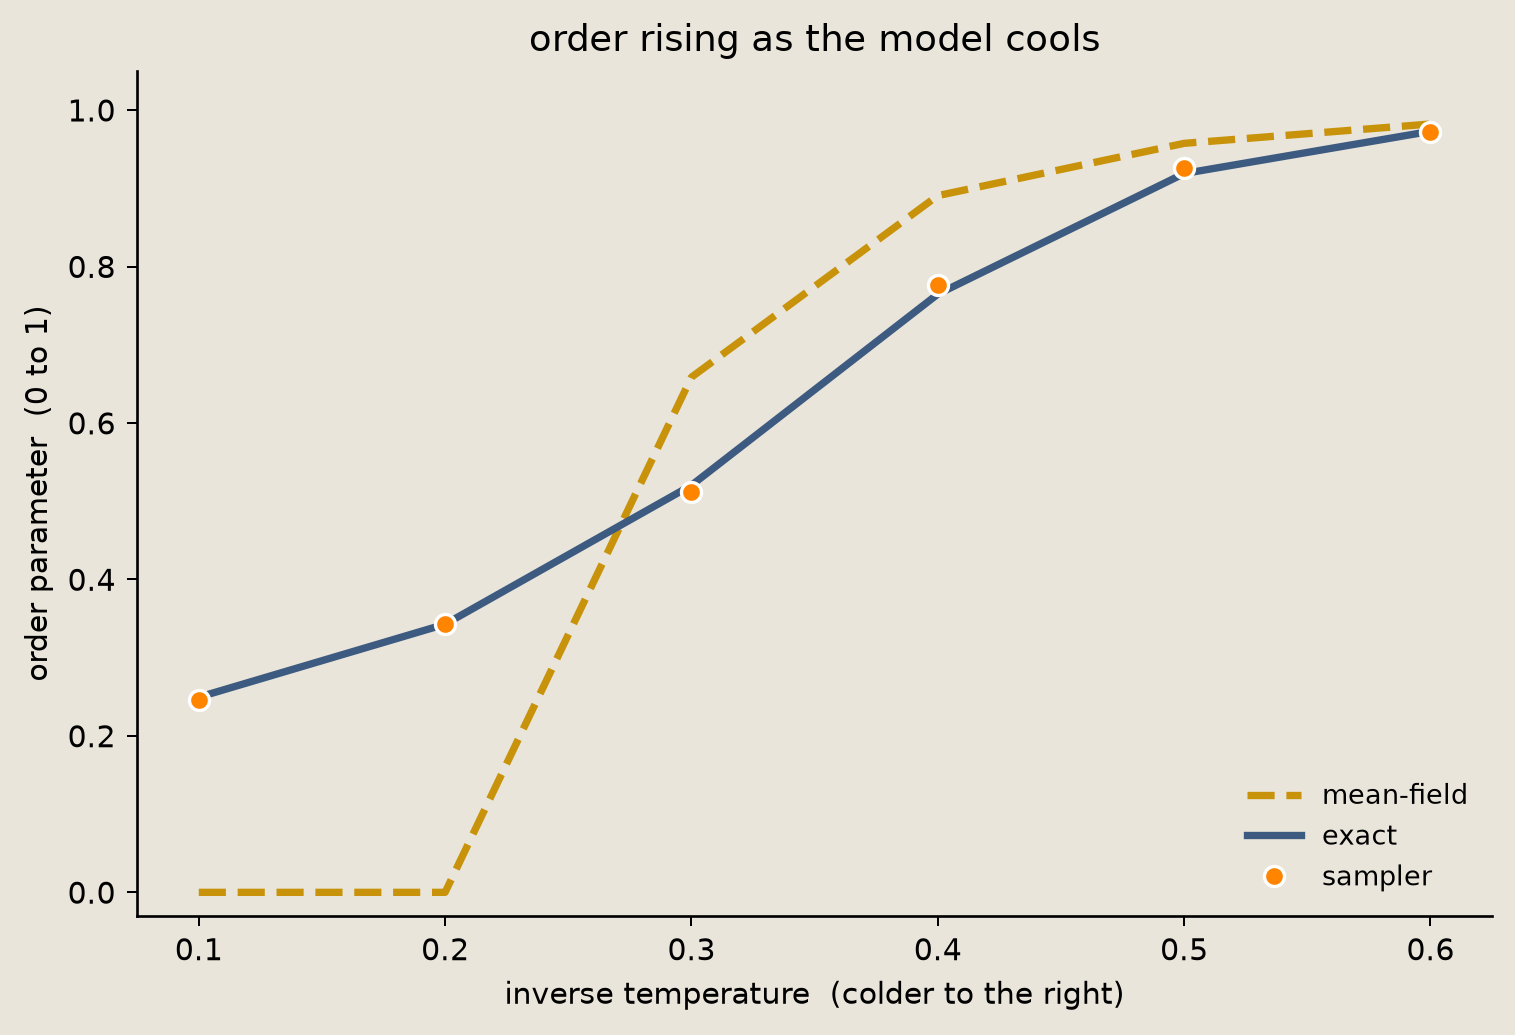

In [35]:
fig = P_samp.plot_temperature_sweep(betas, exact_curve, sampler_curve, mf_curve)
savefig(fig, "16_temperature_sweep")

## Checking against the exact answer

For a fixed field, the Boltzmann distribution over 16 spins is small enough to enumerate, which is what `exact_distribution` computes. With that exact reference in hand, we match the sampler spin by spin and connection by connection.

To make this check meaningful, we drive the model with a field that varies from site to site. The spins are no longer all equivalent.

The left panel shows the average value of each spin. The right panel shows the average agreement across each connection, sampler against exact.

A point on the dashed diagonal means the sampler recovered the exact value. The spread along the diagonal comes from the per-site field.

In [36]:
parity_field = jnp.asarray(rng.normal(0.0, 0.6, size=N), dtype=jnp.float32)

parity_keys = jax.random.split(jax.random.key(SEED + 20), n_chains)
parity_inits = (
    jax.random.bernoulli(jax.random.key(SEED + 21), 0.5, (n_chains, N)).astype(
        jnp.int32
    )
    * 2
    - 1
)
parity_samples = np.asarray(
    run_many(parity_keys, jnp.asarray(beta, jnp.float32), parity_inits, parity_field)
)



In [37]:
# exact per-spin magnetization and per-connection agreement at this field
exact_pf = exact_distribution(np.asarray(parity_field))
exact_spin = (exact_pf[:, None] * ALL_SPINS).sum(axis=0)
exact_conn = np.array(
    [float((exact_pf * ALL_SPINS[:, i] * ALL_SPINS[:, j]).sum()) for i, j in EDGES]
)



In [38]:
# sampler per-spin magnetization and per-connection agreement
sampler_spin = parity_samples.mean(axis=0)
sampler_conn = np.array(
    [(parity_samples[:, i] * parity_samples[:, j]).mean() for i, j in EDGES]
)



In [39]:
spin_err = float(np.max(np.abs(sampler_spin - exact_spin)))
conn_err = float(np.max(np.abs(sampler_conn - exact_conn)))
print(f"max per-spin error       = {spin_err:.4f}")
print(f"max per-connection error = {conn_err:.4f}")

max per-spin error       = 0.0293
max per-connection error = 0.0232


Each spin and each connection becomes one point, sampler against exact. Points on the diagonal mean the sampler recovered the exact value.

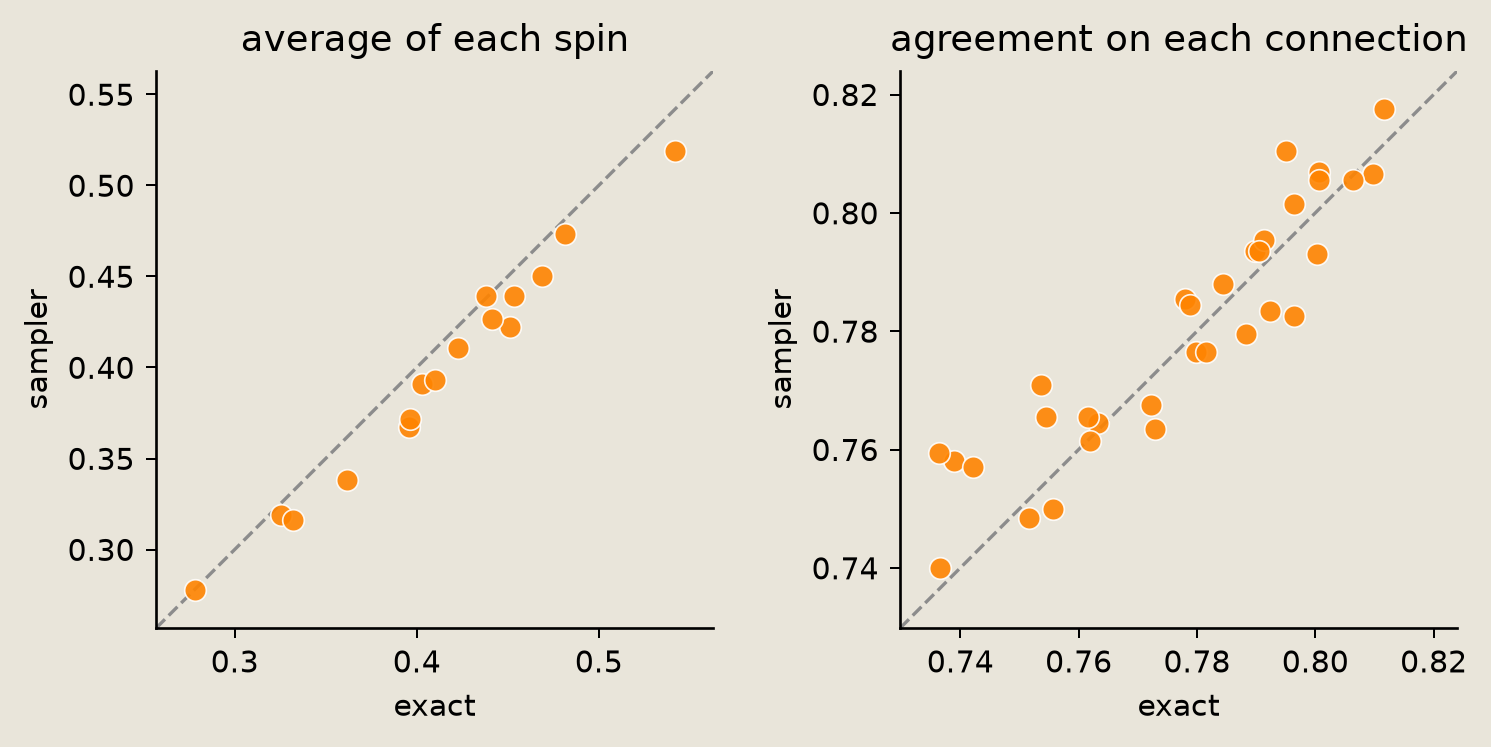

In [40]:
fig = P_samp.plot_parity(exact_spin, sampler_spin, exact_conn, sampler_conn)
savefig(fig, "16_parity")

## Driving it with a field

Because the `field` is an input, the same graph can complete a pattern.

We set a strong field on a few sites to impose a pattern, leave the rest at zero, and run the chain. The field biases the selected sites rather than clamping them (their values are never held fixed), but at this strength the biased sites almost always hold their imposed sign while the free sites fill in around them, consistent with the couplings. The verification below checks the biased-site marginals against the exact conditional rather than the sign alone.

This is the conditional Boltzmann machine, $P(\text{spins} \mid \text{field})$. Between this and the plots above, only the `field` input changes.

In [41]:
# strongly bias a few top-half sites toward +1 and a few bottom-half toward -1
pattern = np.zeros(N)
pin_up = [0, 3, 5]
pin_down = [10, 12, 15]
pattern[pin_up] = +1.0
pattern[pin_down] = -1.0

strong = 6.0
# the strong field biases the selected sites toward their sign
field = strong * jnp.asarray(pattern, dtype=jnp.float32)



In [42]:
n_complete = 3000
complete_keys = jax.random.split(jax.random.key(SEED + 20), n_complete)
complete_init = (
    jax.random.bernoulli(jax.random.key(SEED + 21), 0.5, (n_complete, N)).astype(
        jnp.int32
    )
    * 2
    - 1
)
completed = np.asarray(
    run_many(complete_keys, jnp.asarray(beta, jnp.float32), complete_init, field)
)

one_sample = completed[0]
average = completed.mean(axis=0)



In [43]:
# exact conditional at this field: run() feeds the kernel beta*field as the drive
# and exact_distribution applies beta to the same raw field, so they match.
exact_complete = exact_distribution(np.asarray(field))
exact_avg = (exact_complete[:, None] * ALL_SPINS).sum(axis=0)



In [44]:
pinned_mask = np.asarray(pattern) != 0.0
# check biased-site marginals and alignment against the exact conditional
pinned_align = float(
    np.mean(np.sign(average[pinned_mask]) == np.sign(np.asarray(pattern)[pinned_mask]))
)
pinned_marginal_err = float(np.max(np.abs(average[pinned_mask] - exact_avg[pinned_mask])))
complete_err = float(np.max(np.abs(average - exact_avg)))
print(f"biased sites aligned with their field sign: {pinned_align:.0%}")
print(f"biased-site marginal max error vs exact:   {pinned_marginal_err:.4f}")
print(f"all-site marginal max error vs exact:      {complete_err:.4f}")

biased sites aligned with their field sign: 100%
biased-site marginal max error vs exact:   0.0039
all-site marginal max error vs exact:      0.0316


Across the three panels (the biasing field, one completed sample, and the average), the biased sites hold their sign while the free sites fill in around them.

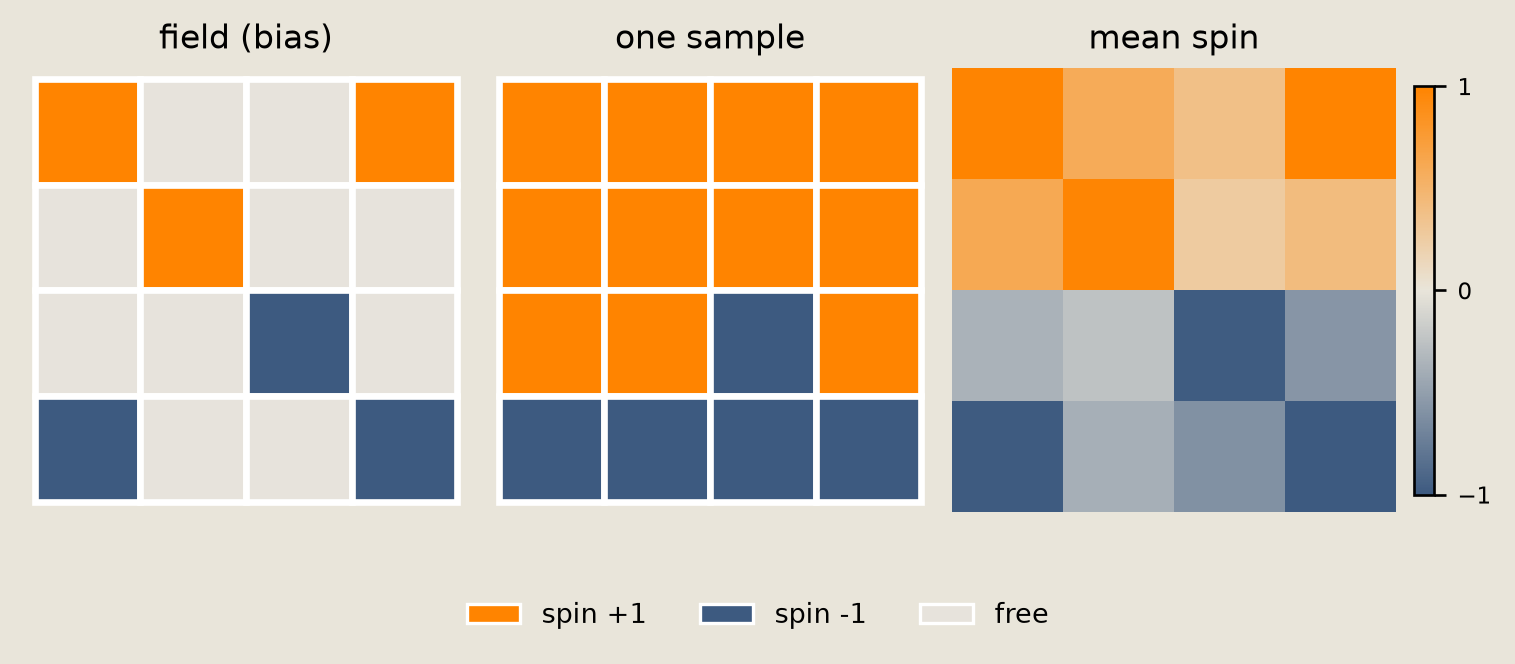

In [45]:
fig = P_samp.plot_pattern_completion(np.asarray(pattern), one_sample, average)
savefig(fig, "16_pattern_completion")

## Verification

We gather the quantitative checks for this tutorial in one place. The single-spin probe compares the draw against its analytic sigmoid conditional. The magnetization, per-spin, per-connection, temperature, and field-completion checks all compare against the brute-force exact distribution.

In [46]:
# enforce the printed claims instead of only printing them
assert abs(probe_p - target_p) < 0.02, (
    f"single-spin probe {probe_p:.4f} off target {target_p:.4f}"
)
assert mag_gap < 0.10, f"magnetization gap {mag_gap:.4f} >= 0.10"
assert spin_err < 0.10, f"max per-spin error {spin_err:.4f} >= 0.10"
assert conn_err < 0.10, f"max per-connection error {conn_err:.4f} >= 0.10"
# cooling raises the order parameter monotonically (warm -> cold)
np.testing.assert_array_less(-np.diff(exact_curve), 1e-9)
assert exact_curve[-1] > exact_curve[0], "order parameter did not rise with cooling"
# temperature sweep: the sampler curve tracks the exact enumeration
temp_err = float(np.max(np.abs(sampler_curve - exact_curve)))
assert temp_err < 0.08, f"temperature sweep off exact by {temp_err:.4f}"
# field-driven completion: sampler marginals match the exact conditional and the
# biased sites align with their imposed sign
assert complete_err < 0.10, f"completion marginal error {complete_err:.4f} >= 0.10"
assert pinned_align > 0.99, f"biased sites did not align: {pinned_align:.2f}"



In [47]:
print("all checks passed")
print(f"  single-spin probe        = {probe_p:.4f}  (target {target_p:.4f})")
print(f"  magnetization gap        = {mag_gap:.4f}  (< 0.10)")
print(f"  max per-spin error       = {spin_err:.4f}  (< 0.10)")
print(f"  max per-connection error = {conn_err:.4f}  (< 0.10)")
print(f"  temperature sweep error  = {temp_err:.4f}  (< 0.08)")
print(f"  completion marginal err  = {complete_err:.4f}  (< 0.10)")
print(f"  order parameter warm->cold = {exact_curve[0]:.3f} -> {exact_curve[-1]:.3f}")

all checks passed
  single-spin probe        = 0.9183  (target 0.9168)
  magnetization gap        = 0.0222  (< 0.10)
  max per-spin error       = 0.0293  (< 0.10)
  max per-connection error = 0.0232  (< 0.10)
  temperature sweep error  = 0.0118  (< 0.08)
  completion marginal err  = 0.0316  (< 0.10)
  order parameter warm->cold = 0.249 -> 0.973


## Conclusion

We built a Boltzmann machine from hand-written factors, sampled it with Gibbs, and checked it against an exact brute-force reference.

- A single spin update is one factor: a directed conditional that draws a pbit with value $1$ with probability $\sigma(2\gamma_i)$ and reports that same conditional through `log_probability`. The probe confirmed that both the draw and the analytic value land on that sigmoid.
- The two checkerboard colors are two Gibbs blocks, each with the same factor tiled across its eight spins and one shared coupling. The `DeterministicFactor` object reassembles them into one state, giving an explicit three-site `DFG` for one Gibbs sweep.
- The weight-tied `ChainFactor` object repeats the sweep into an MCMC chain. After warmup, it samples the Ising magnet to within a small distance of the exact distribution, spin by spin and connection by connection.
- Cooling the model raises the order parameter through the finite-size crossover. The mean-field approximation overshoots there, and the sampler tracks the exact curve.
- Because the `field` is an input, we used the same graph to complete a clamped pattern with no change to the wiring, giving the conditional Boltzmann machine $P(\text{spins} \mid \text{field})$.

[Notebook 06](06_ising_sampling_contrastive_divergence.ipynb) applies the same chromatic-Gibbs conditional idea with `PNOT` gates on an 8-spin ring. This tutorial writes that conditional as factors on a $4\times4$ torus, so the two share the update rule and coloring strategy while their graphs and Ising distributions differ.

This is a `DFG` example. For Gibbs sampling as a tool, use [thrml](https://github.com/extropic-ai/thrml).

## References

1. Extropic. 2026. [thrml](https://github.com/extropic-ai/thrml). This is the dedicated Gibbs sampling library mentioned in the motivation.
2. Extropic. 2026. [Notebook 06: Ising sampling and contrastive divergence](06_ising_sampling_contrastive_divergence.ipynb). This companion notebook reaches the same Ising distribution from the gate side.
3. Extropic. 2026. [Notebook 15: Introduction to factors and directed factor graphs](15_intro_to_factors.ipynb). This companion notebook introduces the factor and `DFG` APIs used here.
4. Ackley, D.H., Hinton, G.E., Sejnowski, T.J. 1985. [*A learning algorithm for Boltzmann machines*](https://www.cs.toronto.edu/~hinton/absps/cogscibm.pdf). Cognitive Science 9(1), 147-169.

